In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [8]:
#data initialize
data = {
    'years_experience' :[1.1, 1.5, 2.0, 2.4, 3.0, 3.2, 3.7, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0, 10.5], # dictionary needs comma btw different columns
    'salary' :[38000, 42000, 44000, None, 52000, 48000, 55000, 58000, None, 65000, 63000, 72000, 68000, 75000, None, 83000, 88000, 92000, 105000, 98000]
}
df = pd.DataFrame(data)  #building 2D frame - (box of limits)
print(df.head())  #shows top 5 row ,col
print(df.shape)  #dimensions of box
print("\nMissing values:\n", df.isnull().sum()) #prints Nan not a number for null

   years_experience   salary
0               1.1  38000.0
1               1.5  42000.0
2               2.0  44000.0
3               2.4      NaN
4               3.0  52000.0
(20, 2)

Missing values:
 years_experience    0
salary              3
dtype: int64


In [9]:
df['salary'] = df['salary'].fillna(df['salary'].median())  #fills null or none values in salary with median value i.e middle val
print(df.isnull().sum()) #now should show 0 values as it is filled
print(df.head(10)) #checking if none values filled by median


years_experience    0
salary              0
dtype: int64
   years_experience   salary
0               1.1  38000.0
1               1.5  42000.0
2               2.0  44000.0
3               2.4  65000.0
4               3.0  52000.0
5               3.2  48000.0
6               3.7  55000.0
7               4.0  58000.0
8               4.5  65000.0
9               5.0  65000.0


In [19]:
#TRAINING PHASE
X = df[['years_experience']]  #def input col
Y = df['salary'] #def output col

#setting up to train model

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
#random_stae for random 4 values to be chose to predict ie 20% of input passed ..
#size = 0.2 = 20% i.e 20rows * 20% = 4rows test ... rest 80% train model

print("Testing rows:" , len(X_train))
print("Testing rows:", len(X_test))
model= LinearRegression()   #create model
model.fit(X_train,Y_train)   #train on 16 r,c
print("Model trained!")

Testing rows: 16
Testing rows: 4
Model trained!


In [20]:
#TESTING PHASE
Y_pred = model.predict(X_test)  #predict salary for 4 unseen rows

print("Actual salaries: ", list(Y_test))
print("Predicted salaries: ", list(Y_pred.round().flatten().tolist()))
#round just displays rounded val but R is calc for full only , flatten removes array[..] in output remove extra wrapper
print("\nR² score:", model.score(X_test, Y_test))

Actual salaries:  [38000.0, 92000.0, 83000.0, 42000.0]
Predicted salaries:  [41223.0, 88208.0, 82261.0, 43602.0]

R² score: 0.9879041529887993


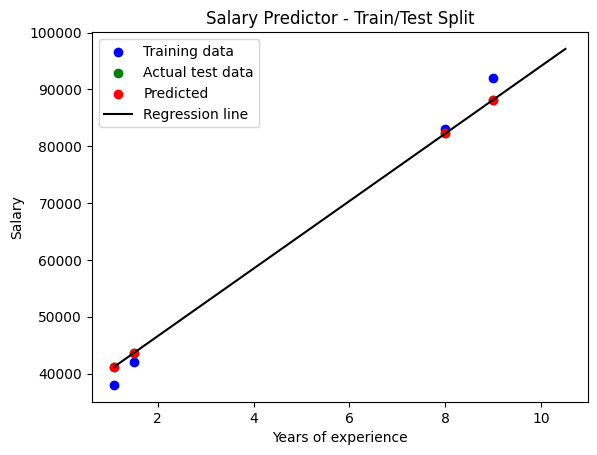

In [21]:
plt.scatter(X_test, Y_test, color='blue', label='Training data')
plt.scatter(X_test, Y_pred, color='green', label='Actual test data')
plt.scatter(X_test, Y_pred, color='red', label='Predicted')

#indv dots , no connection for raw data points

line = model.predict(X)
plt.plot(X, line, color='black', label='Regression line') #connects using line dots
plt.xlabel('Years of experience')
plt.ylabel("Salary")
plt.title("Salary Predictor - Train/Test Split")
plt.legend() #list of labels with colors
plt.show()